# Oil & Gas Topside: Production & Energy Optimization

This notebook demonstrates NeqSim's **production optimization** and **energy optimization** functionality on the same oil/gas separation + recompression process used in the NeqSim-Colab `comparesimulations.ipynb` example.

The base process is built from the reference Java class `neqsim.process.examples.OilGasProcessSimulationOptimization` (HP/MP/LP three-stage separation, three-stage gas recompression, dew-point control, and two export compressors). A **final sales-gas export compressor train** is then added as a **separate process area**, so the overall simulation becomes a multi-area `ProcessModel`.

Four optimization studies are shown:

1. **Production (throughput) optimization** — maximise sales-gas production by varying well feed rate to the bottleneck (`ProductionOptimizer`).
2. **Energy optimization** — minimise total compression power by optimising the inter-stage export pressure split (`ProductionOptimizer`, MINIMIZE objective).
3. **Full-plant throughput-to-bottleneck** — find the maximum feed multiplier the whole multi-area plant can sustain (`ProcessModelThroughputOptimizer`).
4. **Multi-objective Pareto** — production vs energy trade-off (`ProductionOptimizer.optimizePareto`).

> Units: temperature in Kelvin, pressure in bara (NeqSim Java API convention).

In [10]:
# --- Devtools setup: load NeqSim Java classes from the workspace (target/classes) ---
import os
import sys
from pathlib import Path


def find_neqsim_project_root():
    env_root = os.environ.get('NEQSIM_PROJECT_ROOT')
    candidates = []
    if env_root:
        candidates.append(Path(env_root).resolve())
    cwd = Path.cwd().resolve()
    candidates.extend([cwd] + list(cwd.parents))
    for candidate in candidates:
        if (candidate / 'pom.xml').exists() and (
            candidate / 'devtools' / 'neqsim_dev_setup.py'
        ).exists():
            return candidate
    raise RuntimeError('Could not find NeqSim project root. Set NEQSIM_PROJECT_ROOT.')


PROJECT_ROOT = find_neqsim_project_root()
sys.path.insert(0, str(PROJECT_ROOT / 'devtools'))

from neqsim_dev_setup import neqsim_init, neqsim_classes

ns = neqsim_init(project_root=PROJECT_ROOT, recompile=False, verbose=True)
ns = neqsim_classes(ns)
NEQSIM_MODE = 'devtools'
print('NeqSim ready from', PROJECT_ROOT)

NeqSim project root: C:\Users\ESOL\Documents\GitHub\neqsim
JVM already running — reusing existing JVM
All NeqSim classes imported OK
NeqSim ready from C:\Users\ESOL\Documents\GitHub\neqsim


In [11]:
# Imports for jpype functional interfaces and plotting
import jpype
from jpype import JImplements, JOverride
import numpy as np
import matplotlib.pyplot as plt

# Java optimizer classes
OilGasProcess = ns.JClass(
    'neqsim.process.examples.OilGasProcessSimulationOptimization')
ProductionOptimizer = ns.JClass(
    'neqsim.process.util.optimizer.ProductionOptimizer')
OptimizationConfig = ProductionOptimizer.OptimizationConfig
ManipulatedVariable = ProductionOptimizer.ManipulatedVariable
OptimizationObjective = ProductionOptimizer.OptimizationObjective
SearchMode = ProductionOptimizer.SearchMode
ObjectiveType = ProductionOptimizer.ObjectiveType
ProcessModel = ns.JClass('neqsim.process.processmodel.ProcessModel')
ProcessModelThroughputOptimizer = ns.JClass(
    'neqsim.process.util.optimizer.ProcessModelThroughputOptimizer')
Compressor = ns.JClass('neqsim.process.equipment.compressor.Compressor')
Cooler = ns.JClass('neqsim.process.equipment.heatexchanger.Cooler')
Arrays = jpype.JClass('java.util.Arrays')
print('Classes loaded.')

Classes loaded.


## 1. Build the base topside process (Area 1)

The reference Java class constructs the well fluid (PR-EOS, C7+ characterised) and the full separation + recompression flowsheet. We call `createProcess()` and apply the default operating setpoints with `updateInput(...)`. We do **not** run it yet — the export area is added first so both areas converge together inside the `ProcessModel`.

In [12]:
sim = OilGasProcess()
process = sim.createProcess()        # Area 1 ProcessSystem ('Topside process')
process.setName('Topside process')
sim.updateInput(sim.getInputParameters())  # apply default setpoints

compressor_names = ['23-KA-03', '23-KA-02', '23-KA-01', '27-KA-01']
print('Base process units:', process.size())
print('Export gas stream present:',
      process.getUnit('export gas') is not None)

Base process units: 42
Export gas stream present: True


## 2. Add the sales-gas export compressor train (Area 2)

A separate `ProcessSystem` boosts the topside *export gas* (~189 bara) up to a **pipeline sales pressure of 230 bara** with an after-cooler to 30 degC. The Area-1 `export gas` stream object is shared **by reference** as the Area-2 feed — the canonical NeqSim cross-area coupling pattern. Both areas are then combined in a `ProcessModel` and solved together.

In [13]:
ProcessSystem = ns.JClass('neqsim.process.processmodel.ProcessSystem')

export_area = ProcessSystem()
export_area.setName('Export compression')

export_gas = process.getUnit('export gas')   # shared by reference from Area 1

sales_compressor = Compressor('30-KA-01', export_gas)
sales_compressor.setOutletPressure(230.0, 'bara')
sales_compressor.setIsentropicEfficiency(0.78)

sales_cooler = Cooler('30-HA-01', sales_compressor.getOutletStream())
sales_cooler.setOutTemperature(273.15 + 30.0)
sales_cooler.getOutletStream().setName('sales gas export')

export_area.add(sales_compressor)
export_area.add(sales_cooler)
export_area.add(sales_cooler.getOutletStream())

plant = ProcessModel()
plant.add('Topside process', process)
plant.add('Export compression', export_area)

plant.run()
print('Multi-area ProcessModel solved.')

# --- Define a consistent, explicit capacity basis for every compressor ----
# The reference flowsheet ships its compressors without a design basis, so
# the built-in surge-margin constraint has no chart to measure distance-to-
# surge against and defaults to 'at surge' = 100% utilization that never
# responds to feed rate. For a clean optimization example we instead set an
# explicit installed shaft power per machine (130% of the base operating
# point = 23% design margin) and keep ONLY the power-based capacity metric.
# Utilization then equals power / installed_power, which scales smoothly with
# feed so the optimizer can locate a genuine feasible interior point.
DESIGN_POWER_MARGIN = 1.30  # installed power = 1.30 x base operating power


def set_compressor_capacity(comp, margin=DESIGN_POWER_MARGIN):
    base_kw = float(comp.getPower('kW'))
    installed_kw = max(base_kw * margin, 100.0)
    comp.initMechanicalDesign()  # creates the CompressorMechanicalDesign
    comp.getMechanicalDesign().setMaxDesignPower(installed_kw)
    constraints = comp.getCapacityConstraints()  # lazily inits defaults
    # Keep only the shaft-power constraint; disable chart/speed/surge metrics
    for key in ['speed', 'minSpeed', 'surgeMargin', 'stonewallMargin',
                'ratedPower']:
        cstr = constraints.get(key)
        if cstr is not None:
            cstr.setEnabled(False)
    return installed_kw


for _name in compressor_names:
    set_compressor_capacity(process.getUnit(_name))
set_compressor_capacity(export_area.getUnit('30-KA-01'))
plant.run()
print('Compressor capacity basis set (power-limited); plant re-solved.')


Multi-area ProcessModel solved.
Compressor capacity basis set (power-limited); plant re-solved.


In [14]:
# --- Helper functions -------------------------------------------------
def stream_flow(proc, name, unit='kg/hr'):
    return float(proc.getUnit(name).getFlowRate(unit))


def area1_compressor_power_kw(proc):
    total = 0.0
    for n in compressor_names:
        try:
            total += float(proc.getUnit(n).getPower('kW'))
        except Exception:
            pass
    return total


def plant_total_power_kw():
    # Plant-wide aggregate over all ProcessModel areas (compressors + pumps).
    return float(plant.getPower('kW'))


base_feed_kgph = stream_flow(process, 'well stream', 'kg/hr')
base_sales_gas = stream_flow(export_area, 'sales gas export', 'kg/hr')
base_export_oil = stream_flow(process, 'export oil', 'kg/hr')
base_power = plant_total_power_kw()

print(f'Base feed rate      : {base_feed_kgph:10.1f} kg/hr')
print(f'Sales gas export    : {base_sales_gas:10.1f} kg/hr')
print(f'Export oil          : {base_export_oil:10.1f} kg/hr')
print(f'Total compression   : {base_power:10.1f} kW')
print(f'Plant cooler duty   : {plant.getCoolerDuty("MW"):10.3f} MW')
print(f'Plant heater duty   : {plant.getHeaterDuty("MW"):10.3f} MW')

Base feed rate      :   667592.2 kg/hr
Sales gas export    :   107628.3 kg/hr
Export oil          :   556997.5 kg/hr
Total compression   :    11129.7 kW
Plant cooler duty   :    -25.381 MW
Plant heater duty   :    -19.865 MW


## 3. Production (throughput) optimization

`ProductionOptimizer` searches the well feed rate that maximises sales-gas production while respecting equipment capacity constraints. Each compressor was given an explicit installed shaft power (130% of its base operating point) in the cell above, so its utilization equals power / installed_power and scales smoothly with feed, giving the optimizer a genuine feasible interior point instead of a degenerate constraint pinned at 100%. A single decision variable (well feed rate) is searched with golden-section on a composite score. Iteration count is kept modest because each evaluation runs the full recycle flowsheet.

In [15]:
@JImplements('java.util.function.BiConsumer')
class FeedRateSetter:
    @JOverride
    def accept(self, proc, value):
        proc.getUnit('well stream').setFlowRate(float(value), 'kg/hr')


@JImplements('java.util.function.ToDoubleFunction')
class SalesGasObjective:
    @JOverride
    def applyAsDouble(self, proc):
        # Area-1 export gas is the precursor to sales gas; use it as the
        # production proxy that the single-system optimizer can read.
        try:
            return float(proc.getUnit('export gas').getFlowRate('kg/hr'))
        except Exception:
            return 0.0


feed_var = ManipulatedVariable(
    'well feed', 0.5 * base_feed_kgph, 1.5 * base_feed_kgph, 'kg/hr',
    FeedRateSetter())

prod_config = (OptimizationConfig(0.5 * base_feed_kgph, 1.5 * base_feed_kgph)
               .searchMode(SearchMode.GOLDEN_SECTION_SCORE)
               .maxIterations(8)
               .tolerance(0.02)
               .rejectInvalidSimulations(True))

prod_objectives = Arrays.asList(
    OptimizationObjective('production', SalesGasObjective(), 1.0,
                          ObjectiveType.MAXIMIZE))

optimizer = ProductionOptimizer()
prod_result = optimizer.optimize(
    process, Arrays.asList(feed_var), prod_config, prod_objectives, None)

prod_opt_feed = float(prod_result.getDecisionVariables().get('well feed'))
print(f'Optimal feed rate   : {prod_opt_feed:10.1f} kg/hr')
print(f'Feasible            : {bool(prod_result.isFeasible())}')
bn = prod_result.getBottleneck()
print('Bottleneck          :', bn.getName() if bn is not None else 'n/a')
print(f'Bottleneck util.    : {float(prod_result.getBottleneckUtilization())*100:6.1f} %')

Optimal feed rate   :   820798.1 kg/hr
Feasible            : True
Bottleneck          : 27-KA-01
Bottleneck util.    :   94.7 %


## 4. Energy optimization (inter-stage pressure split)

Total compression power depends on how the duty is split between the first export compressor (`23-KA-01`) and the final export compressor (`27-KA-01`). There is an optimal intermediate pressure (classically near the geometric mean of suction and discharge) that **minimises total power**. We first map the energy landscape with a short sweep, then let `ProductionOptimizer` pinpoint the minimum with a MINIMIZE objective. The feed rate is held at its base value during this study.

In [16]:
# Restore base feed before the energy study
process.getUnit('well stream').setFlowRate(base_feed_kgph, 'kg/hr')
plant.run()

# --- Energy landscape sweep over the 23-KA-01 discharge pressure ---
sweep_p = np.linspace(70.0, 120.0, 6)
sweep_power = []
for p in sweep_p:
    process.getUnit('23-KA-01').setOutletPressure(float(p), 'bara')
    plant.run()
    sweep_power.append(plant_total_power_kw())
sweep_power = np.array(sweep_power)
for p, w in zip(sweep_p, sweep_power):
    print(f'P(23-KA-01) = {p:6.1f} bara  ->  total power = {w:9.1f} kW')

P(23-KA-01) =   70.0 bara  ->  total power =    9674.8 kW
P(23-KA-01) =   80.0 bara  ->  total power =   10404.6 kW
P(23-KA-01) =   90.0 bara  ->  total power =   11065.9 kW
P(23-KA-01) =  100.0 bara  ->  total power =   11672.4 kW
P(23-KA-01) =  110.0 bara  ->  total power =   12234.0 kW
P(23-KA-01) =  120.0 bara  ->  total power =   12758.0 kW


In [17]:
@JImplements('java.util.function.BiConsumer')
class InterstageSetter:
    @JOverride
    def accept(self, proc, value):
        proc.getUnit('23-KA-01').setOutletPressure(float(value), 'bara')


@JImplements('java.util.function.ToDoubleFunction')
class Area1PowerObjective:
    @JOverride
    def applyAsDouble(self, proc):
        return area1_compressor_power_kw(proc)


interstage_var = ManipulatedVariable(
    'P_23KA01', 70.0, 120.0, 'bara', InterstageSetter())

energy_config = (OptimizationConfig(70.0, 120.0)
                 .searchMode(SearchMode.GOLDEN_SECTION_SCORE)
                 .maxIterations(8)
                 .tolerance(0.05)
                 .rejectInvalidSimulations(True))

energy_objectives = Arrays.asList(
    OptimizationObjective('compression_power', Area1PowerObjective(), 1.0,
                          ObjectiveType.MINIMIZE))

energy_result = optimizer.optimize(
    process, Arrays.asList(interstage_var), energy_config, energy_objectives, None)

opt_interstage = float(energy_result.getDecisionVariables().get('P_23KA01'))
process.getUnit('23-KA-01').setOutletPressure(opt_interstage, 'bara')
plant.run()
opt_power = plant_total_power_kw()
print(f'Optimal interstage P: {opt_interstage:8.1f} bara')
print(f'Min total power     : {opt_power:8.1f} kW')
print(f'Saving vs base      : {base_power - opt_power:8.1f} kW '
      f'({100*(base_power-opt_power)/base_power:4.1f} %)')

Optimal interstage P:     70.4 bara
Min total power     :   9706.0 kW
Saving vs base      :   1423.6 kW (12.8 %)


## 5. Full-plant throughput-to-bottleneck (`ProcessModelThroughputOptimizer`)

This optimizer works on the whole multi-area `ProcessModel`. It scales the feed by a multiplier and binary-searches the maximum throughput the plant can sustain before a constraint is hit, reporting the active bottleneck area/equipment.

In [18]:
# Reset interstage pressure to its design value for the plant-wide study
process.getUnit('23-KA-01').setOutletPressure(91.01, 'bara')
process.getUnit('well stream').setFlowRate(base_feed_kgph, 'kg/hr')
plant.run()


@JImplements('java.util.function.ToDoubleFunction')
class PlantSalesGasObjective:
    @JOverride
    def applyAsDouble(self, model):
        try:
            area = model.get('Export compression')
            return float(area.getUnit('sales gas export').getFlowRate('kg/hr'))
        except Exception:
            return 0.0


throughput_opt = ProcessModelThroughputOptimizer(plant)
throughput_opt.addProducer(
    'Feed', 'Topside process::well stream.flowRate', 0.8, 1.4, 'kg/hr')
throughput_opt.setObjective('Sales gas', PlantSalesGasObjective(), 'kg/hr')

tp_result = throughput_opt.findMaximumThroughput(0.8, 1.4, 0.03)

best = tp_result.getBestFeasibleCase()
if best is not None:
    print(f'Max feed multiplier : {best.getThroughputMultiplier():6.3f}')
    print(f'Sales gas at max    : {best.getObjectiveValue():10.1f} kg/hr')
    print('Active bottleneck   :', best.getActiveEquipment(),
          '(', best.getActiveArea(), ')')
else:
    print('No feasible case found in the multiplier range.')
infeasible = tp_result.getFirstInfeasibleCase()
if infeasible is not None:
    print(f'First infeasible mult: {infeasible.getThroughputMultiplier():6.3f}'
          ' ->', infeasible.getActiveConstraint())

Max feed multiplier :  1.288
Sales gas at max    :   139394.3 kg/hr
Active bottleneck   : 30-KA-01 ( Export compression )
First infeasible mult:  1.306 -> power


## 6. Multi-objective Pareto: production vs energy

`optimizePareto` finds the trade-off front between two competing objectives. Here we trade **production** (maximise export gas) against **energy** (minimise Area-1 compression power) as the well feed rate varies. A small weight grid keeps the run tractable on this recycle-heavy flowsheet.

In [19]:
process.getUnit('well stream').setFlowRate(base_feed_kgph, 'kg/hr')
plant.run()

pareto_feed_var = ManipulatedVariable(
    'well feed', 0.5 * base_feed_kgph, 1.5 * base_feed_kgph, 'kg/hr',
    FeedRateSetter())

pareto_config = (OptimizationConfig(0.5 * base_feed_kgph, 1.5 * base_feed_kgph)
                 .searchMode(SearchMode.GOLDEN_SECTION_SCORE)
                 .maxIterations(5)
                 .tolerance(0.05)
                 .paretoGridSize(3)
                 .rejectInvalidSimulations(True))

pareto_objectives = Arrays.asList(
    OptimizationObjective('production', SalesGasObjective(), 1.0,
                          ObjectiveType.MAXIMIZE),
    OptimizationObjective('energy', Area1PowerObjective(), 1.0,
                          ObjectiveType.MINIMIZE))

pareto_result = optimizer.optimizePareto(
    process, Arrays.asList(pareto_feed_var), pareto_config, pareto_objectives, None)

pareto_prod = []
pareto_energy = []
for pt in pareto_result.getParetoFront():
    ov = pt.getObjectiveValues()
    pareto_prod.append(float(ov.get('production')))
    pareto_energy.append(float(ov.get('energy')))
print(f'Pareto front points : {pareto_result.getParetoFrontSize()}')
for pr, en in sorted(zip(pareto_prod, pareto_energy)):
    print(f'  production = {pr:9.1f} kg/hr   energy = {en:9.1f} kW')

Pareto front points : 3
  production =   56188.0 kg/hr   energy =    4958.7 kW
  production =  132984.5 kg/hr   energy =   11497.1 kW
  production =  132984.5 kg/hr   energy =   11497.1 kW


## 7. Visualizations

Three figures: the energy landscape (total power vs interstage pressure), the production-vs-energy Pareto front, and a base-case KPI summary.

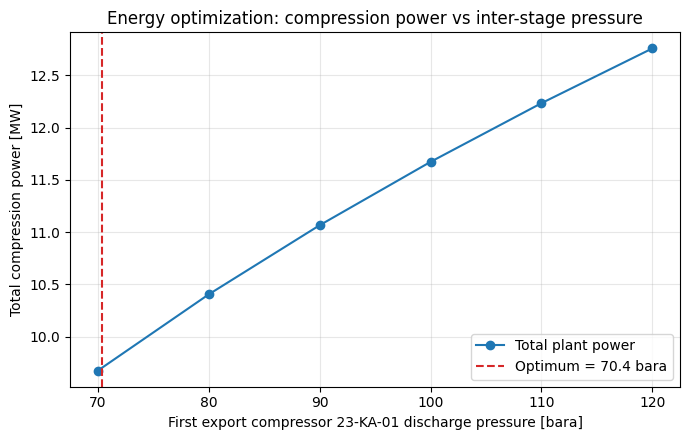

In [20]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(sweep_p, sweep_power / 1e3, 'o-', color='tab:blue', label='Total plant power')
ax.axvline(opt_interstage, color='tab:red', ls='--',
           label=f'Optimum = {opt_interstage:.1f} bara')
ax.set_xlabel('First export compressor 23-KA-01 discharge pressure [bara]')
ax.set_ylabel('Total compression power [MW]')
ax.set_title('Energy optimization: compression power vs inter-stage pressure')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

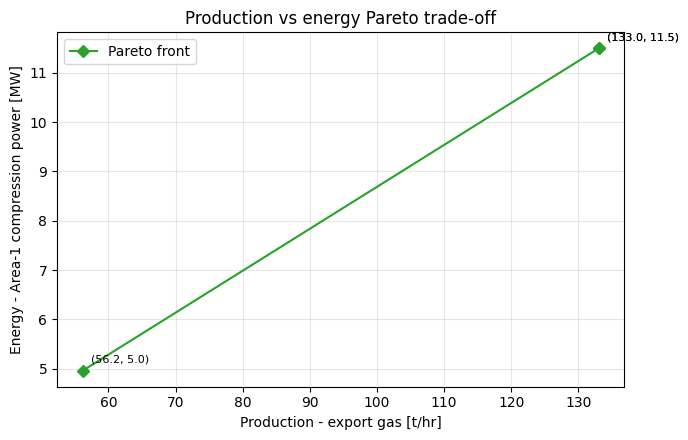

In [21]:
fig, ax = plt.subplots(figsize=(7, 4.5))
if pareto_prod:
    order = np.argsort(pareto_prod)
    pp = np.array(pareto_prod)[order] / 1e3
    pe = np.array(pareto_energy)[order] / 1e3
    ax.plot(pp, pe, 'D-', color='tab:green', label='Pareto front')
    for x, y in zip(pp, pe):
        ax.annotate(f'({x:.1f}, {y:.1f})', (x, y),
                    textcoords='offset points', xytext=(6, 6), fontsize=8)
ax.set_xlabel('Production - export gas [t/hr]')
ax.set_ylabel('Energy - Area-1 compression power [MW]')
ax.set_title('Production vs energy Pareto trade-off')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

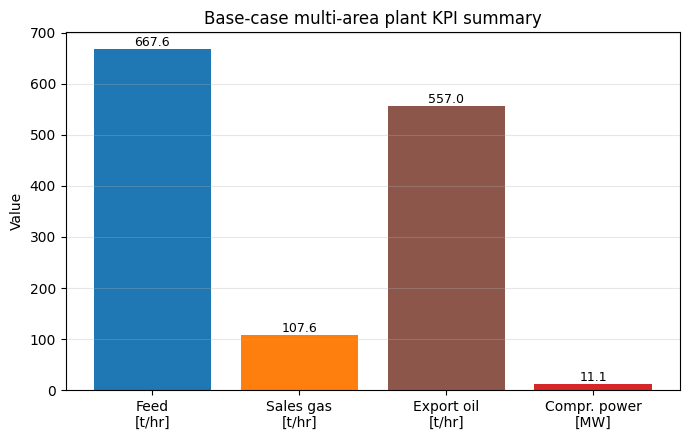

In [22]:
fig, ax = plt.subplots(figsize=(7, 4.5))
labels = ['Feed\n[t/hr]', 'Sales gas\n[t/hr]', 'Export oil\n[t/hr]',
          'Compr. power\n[MW]']
values = [base_feed_kgph / 1e3, base_sales_gas / 1e3,
          base_export_oil / 1e3, base_power / 1e3]
bars = ax.bar(labels, values,
              color=['tab:blue', 'tab:orange', 'tab:brown', 'tab:red'])
for b, v in zip(bars, values):
    ax.text(b.get_x() + b.get_width() / 2, v, f'{v:.1f}',
            ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Value')
ax.set_title('Base-case multi-area plant KPI summary')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Summary

This notebook reproduced the `comparesimulations.ipynb` topside process from the reference Java class, extended it with a sales-gas export compressor area to form a multi-area `ProcessModel`, and demonstrated NeqSim's optimization stack:

- **`ProductionOptimizer`** for single-system throughput maximisation and energy (power) minimisation,
- **`ProcessModelThroughputOptimizer`** for full-plant throughput-to-bottleneck analysis, and
- **`ProductionOptimizer.optimizePareto`** for the production-vs-energy trade-off front.

The energy study shows a clear optimum inter-stage pressure that minimises total compression power, illustrating how setpoint optimisation reduces energy use at fixed throughput.

In [23]:
print('=== Optimization summary ===')
print(f'Base feed rate            : {base_feed_kgph:10.1f} kg/hr')
print(f'Throughput-opt feed rate  : {prod_opt_feed:10.1f} kg/hr')
print(f'Base total power          : {base_power:10.1f} kW')
print(f'Energy-opt total power    : {opt_power:10.1f} kW')
print(f'Energy-opt interstage P   : {opt_interstage:10.1f} bara')
if best is not None:
    print(f'Plant max feed multiplier : {best.getThroughputMultiplier():10.3f}')
print(f'Pareto front points       : {pareto_result.getParetoFrontSize():10d}')

=== Optimization summary ===
Base feed rate            :   667592.2 kg/hr
Throughput-opt feed rate  :   820798.1 kg/hr
Base total power          :    11129.7 kW
Energy-opt total power    :     9706.0 kW
Energy-opt interstage P   :       70.4 bara
Plant max feed multiplier :      1.288
Pareto front points       :          3
